In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

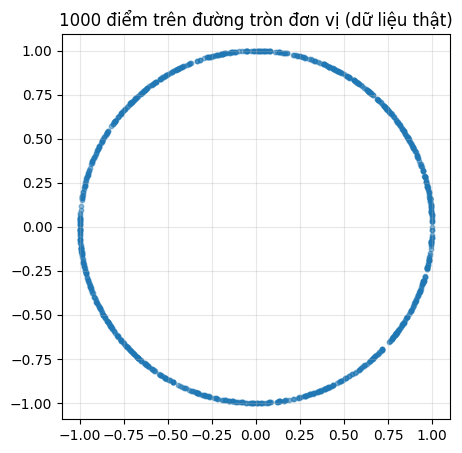

In [ ]:

def make_real_data(n=1000):
    theta = 2 * np.pi * np.random.rand(n)
    x = np.cos(theta); y = np.sin(theta)
    return torch.tensor(np.stack([x, y], axis=1), dtype=torch.float32)

real_data = make_real_data().to(device)

plt.figure(figsize=(5, 5))
plt.scatter(real_data.cpu()[:, 0], real_data.cpu()[:, 1], s=10, alpha=0.5)
plt.title('1000 điểm trên đường tròn đơn vị (dữ liệu thật)')
plt.axis('equal'); plt.grid(alpha=0.3); plt.show()

In [ ]:

noise_dim = 16

class Generator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, out_dim),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),     # trả về logit (chưa sigmoid) — đi với BCEWithLogitsLoss
        )
    def forward(self, x):
        return self.net(x)

G = Generator(noise_dim, 2).to(device)
D = Discriminator(2).to(device)

criterion = nn.BCEWithLogitsLoss()
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
epochs = 8000
batch_size = 64
loss_D_hist, loss_G_hist = [], []
milestones = [0, 1000, 4000, epochs - 1]
snapshots = {}

for epoch in range(epochs):
    # ----- Update D -----
    G.train(); D.train()
    idx = torch.randint(0, len(real_data), (batch_size,))
    real_batch = real_data[idx]
    z = torch.randn(batch_size, noise_dim, device=device)
    fake_batch = G(z).detach()                          # detach để không backprop về G

    real_logits = D(real_batch)
    fake_logits = D(fake_batch)
    loss_D = (criterion(real_logits, torch.ones_like(real_logits)) +
              criterion(fake_logits, torch.zeros_like(fake_logits))) / 2
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()

    # ----- Update G -----
    z = torch.randn(batch_size, noise_dim, device=device)
    fake_batch = G(z)
    fake_logits = D(fake_batch)
    # Non-saturating: G muốn D đánh giá fake là thật → label = 1.
    loss_G = criterion(fake_logits, torch.ones_like(fake_logits))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    loss_D_hist.append(loss_D.item())
    loss_G_hist.append(loss_G.item())

    if epoch in milestones:
        # Khi sample, G phải ở chế độ eval vì có BatchNorm.
        G.eval()
        with torch.no_grad():
            z_vis = torch.randn(1000, noise_dim, device=device)
            snapshots[epoch] = G(z_vis).cpu().numpy()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch+1:5d}/{epochs}  L_D = {loss_D.item():.4f}  L_G = {loss_G.item():.4f}')

Epoch  1000/8000  L_D = 0.6268  L_G = 0.7862
Epoch  2000/8000  L_D = 0.5858  L_G = 0.7903
Epoch  3000/8000  L_D = 0.6188  L_G = 0.8871
Epoch  4000/8000  L_D = 0.5427  L_G = 1.0040
Epoch  5000/8000  L_D = 0.4472  L_G = 0.8141
Epoch  6000/8000  L_D = 0.4041  L_G = 1.7196
Epoch  7000/8000  L_D = 0.4659  L_G = 1.4078
Epoch  8000/8000  L_D = 0.4824  L_G = 2.2974


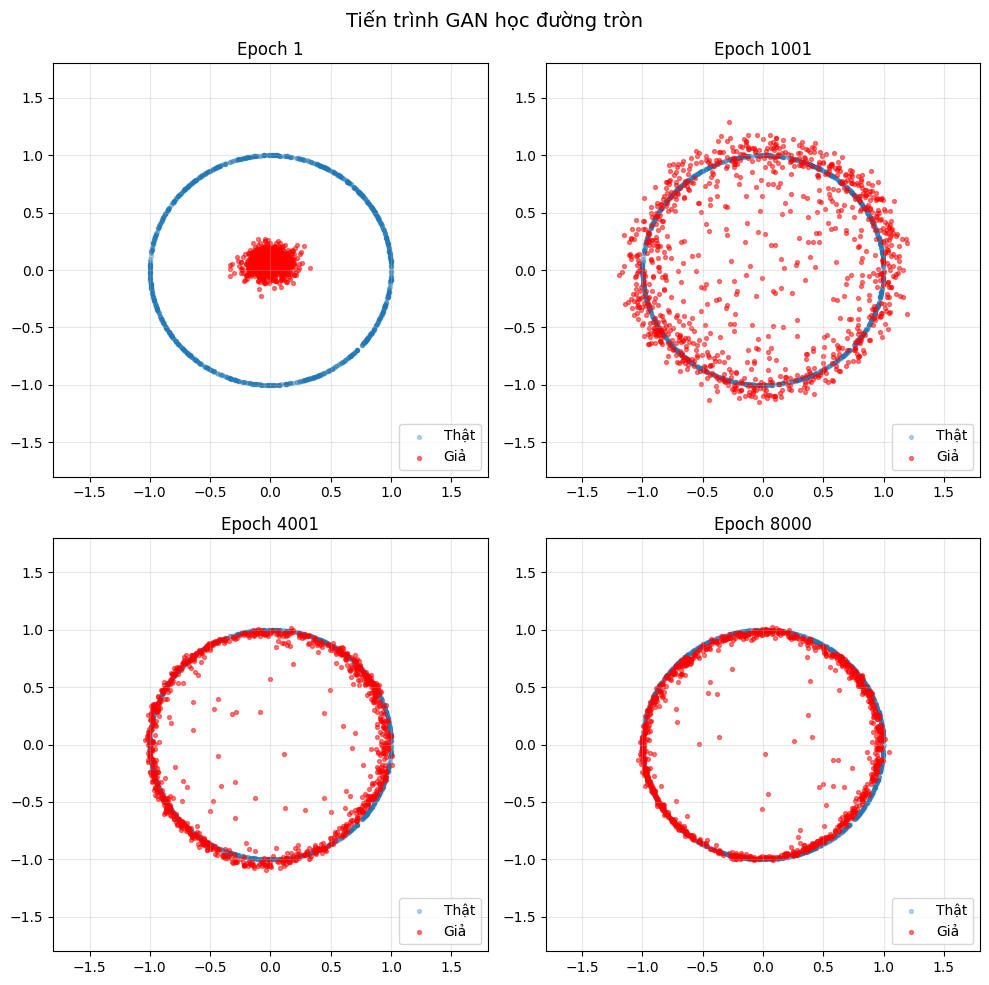

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, ep in zip(axes.flat, milestones):
    fake = snapshots[ep]
    ax.scatter(real_data.cpu()[:, 0], real_data.cpu()[:, 1], s=8, alpha=0.3, label='Thật')
    ax.scatter(fake[:, 0], fake[:, 1], s=8, alpha=0.5, color='red', label='Giả')
    ax.set_title(f'Epoch {ep+1}')
    ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle('Tiến trình GAN học đường tròn', fontsize=14)
plt.tight_layout(); plt.show()


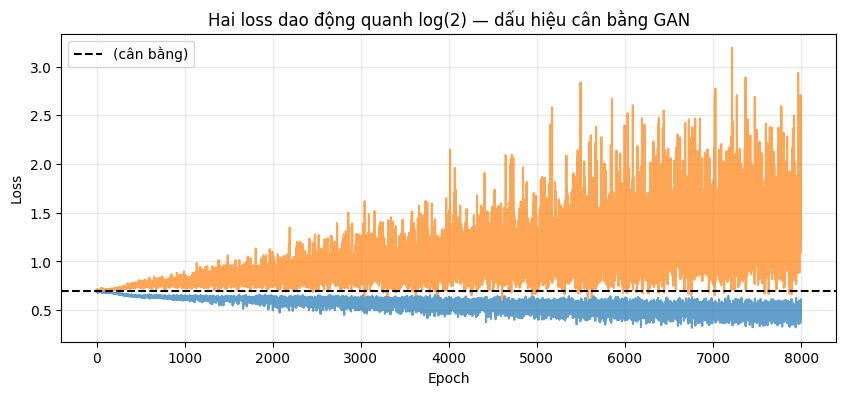

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(loss_D_hist, label='', alpha=0.7)
plt.plot(loss_G_hist, label='', alpha=0.7)
plt.axhline(np.log(2), color='black', linestyle='--', label=r'(cân bằng)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Hai loss dao động quanh log(2) — dấu hiệu cân bằng GAN')
plt.show()

Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 150MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 30.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 42.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


Epoch   1/50  L_D = 0.6456  L_G = 0.8275
Epoch   2/50  L_D = 0.6367  L_G = 0.8976
Epoch   3/50  L_D = 0.6243  L_G = 0.9504
Epoch   4/50  L_D = 0.6098  L_G = 1.0027
Epoch   5/50  L_D = 0.6056  L_G = 1.0162
Epoch   6/50  L_D = 0.6103  L_G = 0.9792
Epoch   7/50  L_D = 0.6164  L_G = 0.9489
Epoch   8/50  L_D = 0.6223  L_G = 0.9300
Epoch   9/50  L_D = 0.6301  L_G = 0.8985
Epoch  10/50  L_D = 0.6327  L_G = 0.8853
Epoch  11/50  L_D = 0.6359  L_G = 0.8795
Epoch  12/50  L_D = 0.6397  L_G = 0.8683
Epoch  13/50  L_D = 0.6455  L_G = 0.8523
Epoch  14/50  L_D = 0.6468  L_G = 0.8459
Epoch  15/50  L_D = 0.6480  L_G = 0.8420
Epoch  16/50  L_D = 0.6523  L_G = 0.8320
Epoch  17/50  L_D = 0.6558  L_G = 0.8254
Epoch  18/50  L_D = 0.6585  L_G = 0.8177
Epoch  19/50  L_D = 0.6604  L_G = 0.8146
Epoch  20/50  L_D = 0.6608  L_G = 0.8121
Epoch  21/50  L_D = 0.6626  L_G = 0.8046
Epoch  22/50  L_D = 0.6630  L_G = 0.8040
Epoch  23/50  L_D = 0.6647  L_G = 0.8010
Epoch  24/50  L_D = 0.6659  L_G = 0.7965
Epoch  25/50  L_

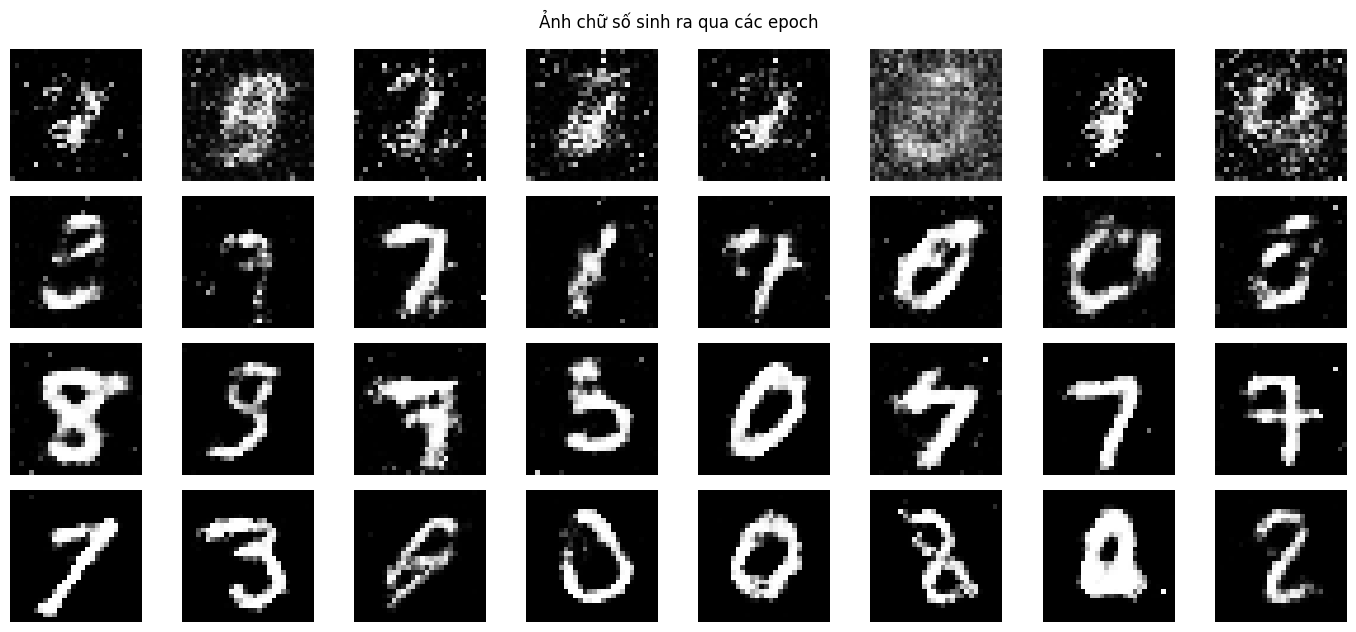

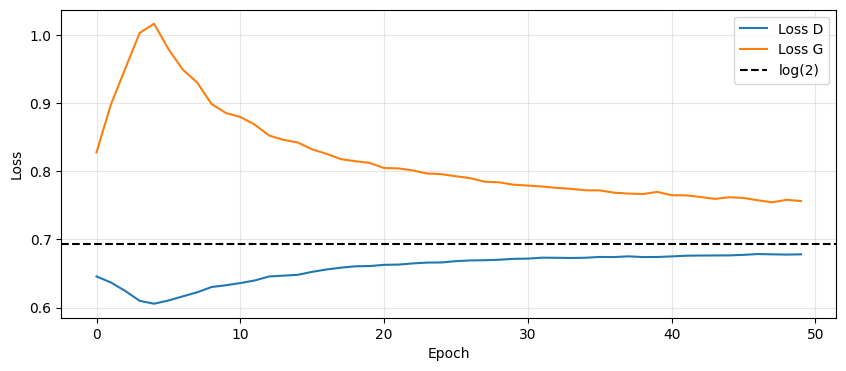

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Chuẩn hoá MNIST về [-1, 1] để tương thích với Tanh ở output của Generator.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(mnist, batch_size=128, shuffle=True, drop_last=True)


z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Hint: chuỗi Linear → LeakyReLU → ... → Tanh.
        # Cấu trúc gợi ý: z_dim(100) → 256 → 512 → 1024 → img_dim(784).
        # Dùng nn.Sequential cho gọn.
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()    # đẩy về [-1, 1] khớp với chuẩn hoá ảnh
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Hint: img_dim(784) → 512 → 256 → 1.
        # KHÔNG có Sigmoid ở cuối — sẽ dùng BCEWithLogitsLoss.
        # Có thể thêm nn.Dropout(0.3) sau LeakyReLU để D không quá khoẻ.
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)


G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))


num_epochs = 50
milestone_epochs = [0, 9, 29, 49]    # 1, 10, 30, 50 (0-indexed)
snapshots = {}
loss_D_hist, loss_G_hist = [], []

for epoch in range(num_epochs):
    G.train(); D.train()
    epoch_loss_D, epoch_loss_G, n_batches = 0.0, 0.0, 0
    for real_imgs, _ in loader:
        bsz = real_imgs.size(0)
        # Đưa ảnh thành vector 784, chuyển lên device.
        real_imgs = real_imgs.view(bsz, -1).to(device)

        # ===== Update D =====
        opt_D.zero_grad()
        real_logits = D(real_imgs)
        z = torch.randn(bsz, z_dim, device=device)
        fake_imgs = G(z).detach()
        fake_logits = D(fake_imgs)
        loss_D = (criterion(real_logits, torch.ones_like(real_logits))
                          + criterion(fake_logits, torch.zeros_like(fake_logits))) / 2
        loss_D.backward(); opt_D.step()

        # ===== Update G =====
        opt_G.zero_grad()
        z = torch.randn(bsz, z_dim, device=device)
        fake_logits = D(G(z))
        loss_G = criterion(fake_logits, torch.ones_like(fake_logits))   # non-saturating
        loss_G.backward(); opt_G.step()

        epoch_loss_D += loss_D.item(); epoch_loss_G += loss_G.item(); n_batches += 1

    loss_D_hist.append(epoch_loss_D / n_batches)
    loss_G_hist.append(epoch_loss_G / n_batches)

    if epoch in milestone_epochs:
        G.eval()
        with torch.no_grad():
            z = torch.randn(16, z_dim, device=device)
            samples = G(z).view(-1, 28, 28).cpu().numpy()
        snapshots[epoch] = samples

    print(f'Epoch {epoch+1:3d}/{num_epochs}  '
          f'L_D = {loss_D_hist[-1]:.4f}  L_G = {loss_G_hist[-1]:.4f}'
          )


# Vẽ ảnh giả ở các milestone
fig, axes = plt.subplots(len(milestone_epochs), 8, figsize=(14, 1.6 * len(milestone_epochs)))
for r, ep in enumerate(milestone_epochs):
    if ep not in snapshots: continue
    for c in range(8):
        axes[r, c].imshow(snapshots[ep][c], cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(f'Epoch {ep+1}', fontsize=12, rotation=0, ha='right', va='center')
plt.suptitle('Ảnh chữ số sinh ra qua các epoch')
plt.tight_layout(); plt.show()

# Vẽ loss
plt.figure(figsize=(10, 4))
plt.plot(loss_D_hist, label='Loss D')
plt.plot(loss_G_hist, label='Loss G')
plt.axhline(np.log(2), color='black', linestyle='--', label='log(2)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.show()